Downloading...
From: https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg
To: /content/actress.jpg
100%|██████████| 39.5k/39.5k [00:00<00:00, 2.61MB/s]


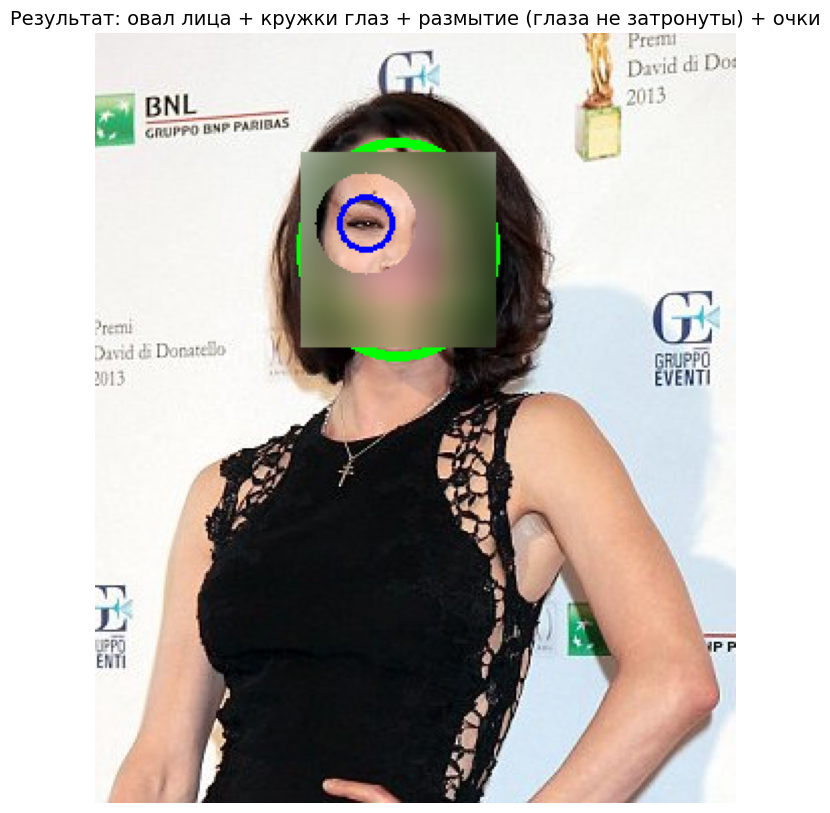

In [5]:
import cv2
import numpy as np
import gdown
from matplotlib import pyplot as plt

# Загружаем фото
image_url = "https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg"
gdown.download(image_url, "actress.jpg", quiet=False)
img = cv2.imread("actress.jpg")
img_copy = img.copy()

# Загружаем каскады Хаара для лица и глаз
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Распознаем лицо
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

if len(faces) == 0:
    print("Лицо не найдено. Попробуйте другое фото.")
else:
    (x, y, w, h) = faces[0]

    # Рисуем ОВАЛ вокруг лица
    center = (x + w // 2, y + h // 2)
    axes = (w // 2, int(h // 1.8))  # Полуоси овала
    cv2.ellipse(img_copy, center, axes, 0, 0, 360, (0, 255, 0), 3)  # Зеленый овал

    # Распознаем глаза внутри лица
    gray_face = gray[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(gray_face, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))
    eye_centers = []

    for (ex, ey, ew, eh) in eyes:
        # Центр глаза
        eye_center = (x + ex + ew//2, y + ey + eh//2)
        eye_centers.append(eye_center)
        radius = int(0.25 * (ew + eh))  # Радиус кружка
        cv2.circle(img_copy, eye_center, radius, (255, 0, 0), 2)  # Синий кружок

    # Размытие лица, не затрагивая глаза
    # Создаем маску: белое = что размываем, черное = что оставляем
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask[y:y+h, x:x+w] = 255  # Вся область лица - белая

    # Вырезаем круги под глаза из маски
    for (cx, cy) in eye_centers:
        cv2.circle(mask, (cx, cy), radius=25, color=0, thickness=-1)

    # Размываем изображение
    blurred = cv2.GaussianBlur(img_copy, (51, 51), 30)

    # Там, где mask=255 лицо без глаз - берем размытое, иначе - оригинал
    img_copy = np.where(mask[:, :, np.newaxis] == 255, blurred, img_copy)

    # Дополнительно: солнцезащитные очки
    # Ссылка на PNG с очками
    glasses_url = "https://storage.yandexcloud.net/quize-backet/glasses.png"
    try:
        gdown.download(glasses_url, "glasses.png", quiet=True)
        glasses = cv2.imread("glasses.png", cv2.IMREAD_UNCHANGED)

        if len(eye_centers) >= 2 and glasses is not None:
            # Сортируем глаза по координате X (левый, правый)
            eye_centers.sort(key=lambda p: p[0])
            left_eye, right_eye = eye_centers[0], eye_centers[1]

            # Расстояние между глазами определяет ширину очков
            eye_distance = abs(right_eye[0] - left_eye[0])
            glasses_width = int(eye_distance * 1.6)
            glasses_height = int(glasses_width * glasses.shape[0] / glasses.shape[1])
            glasses_resized = cv2.resize(glasses, (glasses_width, glasses_height))

            # Позиция для вставки очков (относительно левого глаза)
            glasses_x = left_eye[0] - int(glasses_width * 0.25)
            glasses_y = left_eye[1] - int(glasses_height * 0.6)

            # Накладываем очки с учетом прозрачности (альфа-канал)
            for c in range(3):  # BGR каналы
                img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c] = \
                    glasses_resized[:, :, c] * (glasses_resized[:, :, 3] / 255.0) + \
                    img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c] * (1.0 - glasses_resized[:, :, 3] / 255.0)
            print("Очки успешно добавлены!")
    except Exception as e:
        print(f"Не удалось добавить очки: {e}")

    # Результат
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Результат: овал лица + кружки глаз + размытие (глаза не затронуты) + очки", fontsize=14)
    plt.show()

Downloading...
From: https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg
To: /content/actress.jpg
100%|██████████| 39.5k/39.5k [00:00<00:00, 5.09MB/s]


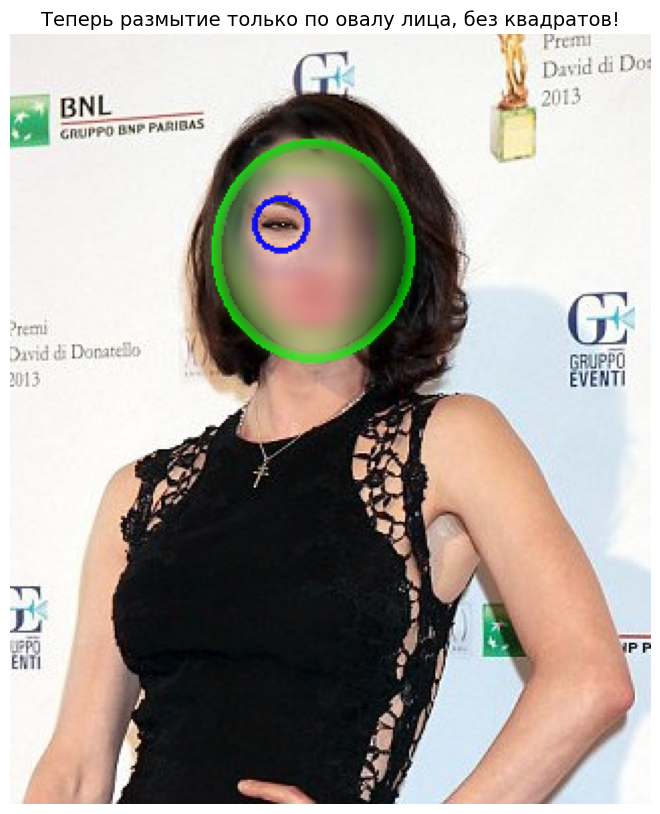

In [8]:
import cv2
import numpy as np
import gdown
from matplotlib import pyplot as plt

# Загружаем фото
image_url = "https://storage.yandexcloud.net/quize-backet/azia_arjento.jpg"
gdown.download(image_url, "actress.jpg", quiet=False)
img = cv2.imread("actress.jpg")
img_copy = img.copy()

# Загружаем каскады
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Распознаём лицо
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

if len(faces) == 0:
    print("Лицо не найдено")
else:
    (x, y, w, h) = faces[0]

    # Рисуем овал вокруг лица
    center = (x + w // 2, y + h // 2)
    axes = (w // 2, int(h // 1.8))
    cv2.ellipse(img_copy, center, axes, 0, 0, 360, (0, 255, 0), 3)

    # Распознаём глаза
    gray_face = gray[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(gray_face, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))
    eye_centers = []
    eye_radiuses = []

    for (ex, ey, ew, eh) in eyes:
        eye_center = (x + ex + ew//2, y + ey + eh//2)
        eye_centers.append(eye_center)
        radius = int(0.25 * (ew + eh))
        eye_radiuses.append(radius)
        cv2.circle(img_copy, eye_center, radius, (255, 0, 0), 2)

    # Создаём маску-овал для размытия
    mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # Рисуем белый ОВАЛ на маске (вот где лицо будет размыто)
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)  # -1 = заливка

    # Вырезаем глаза из маски (чтобы они остались чёткими)
    for (cx, cy), r in zip(eye_centers, eye_radiuses):
        cv2.circle(mask, (cx, cy), r + 5, 0, -1)  # чуть больше самих глаз для плавности

    # Немного размываем границы маски, чтобы переход был мягким
    mask = cv2.GaussianBlur(mask, (15, 15), 5)

    # Размываем всё изображение
    blurred = cv2.GaussianBlur(img_copy, (31, 31), 20)

    # Преобразуем маску из одноканальной в трёхканальную и нормализуем
    mask_3ch = mask[:, :, np.newaxis] / 255.0

    # Плавно смешиваем: чем белее маска, тем сильнее размытие
    img_copy = (blurred * mask_3ch + img_copy * (1 - mask_3ch)).astype(np.uint8)

    # Очки
    glasses_url = "https://storage.yandexcloud.net/quize-backet/glasses.png"
    try:
        gdown.download(glasses_url, "glasses.png", quiet=True)
        glasses = cv2.imread("glasses.png", cv2.IMREAD_UNCHANGED)

        if len(eye_centers) >= 2 and glasses is not None:
            eye_centers.sort(key=lambda p: p[0])
            left_eye, right_eye = eye_centers[0], eye_centers[1]

            eye_distance = abs(right_eye[0] - left_eye[0])
            glasses_width = int(eye_distance * 1.6)
            glasses_height = int(glasses_width * glasses.shape[0] / glasses.shape[1])
            glasses_resized = cv2.resize(glasses, (glasses_width, glasses_height))

            glasses_x = left_eye[0] - int(glasses_width * 0.25)
            glasses_y = left_eye[1] - int(glasses_height * 0.6)

            for c in range(3):
                if glasses_resized[:, :, 3].max() > 0:
                    alpha = glasses_resized[:, :, 3] / 255.0
                    img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c] = \
                        glasses_resized[:, :, c] * alpha + \
                        img_copy[glasses_y:glasses_y+glasses_height, glasses_x:glasses_x+glasses_width, c] * (1 - alpha)
    except:
        pass

    # Результат
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Теперь размытие только по овалу лица, без квадратов!", fontsize=14)
    plt.show()